In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the CSV files
hh = pd.read_csv('LCS2015HOUSEHOLD.csv')
assets = pd.read_csv('LCS2015HOUSEHOLDASSETS.csv')
person_income = pd.read_csv('LCS2015PERSONINCOME.csv')
persons = pd.read_csv('LCS2015PERSONSFINAL.csv')
total = pd.read_csv('LCS2015TOTALLCS.csv')

In [71]:
# Check province codes (expected: 5 = KZN)
hh['province_code'].value_counts()

# Subset household file
kzn_hh = hh[hh['province_code'] == 5].copy()

# Get list of KZN household IDs
kzn_uqnos = kzn_hh['UQNO'].unique()

# Subset other files
kzn_persons = persons[persons['UQNO'].isin(kzn_uqnos)]
kzn_total = total[total['UQNO'].isin(kzn_uqnos)]

In [72]:
# Search for food insecurity columns
fi_keywords = ['224', '225', '226', '227', '222', '223']
for kw in fi_keywords:
    matches = [col for col in kzn_hh.columns if kw in col]
    if matches:
        print(f"Columns containing '{kw}': {matches}")

Columns containing '224': ['Q224ANOMONEY', 'Q224BNOMONEY5']
Columns containing '225': ['Q225ASIZE', 'Q225BSIZE5']
Columns containing '226': ['Q226ASKIP', 'Q226BSKIP5']
Columns containing '227': ['Q227ALESS', 'Q227BLESS5']
Columns containing '222': ['Q222ADULT']
Columns containing '223': ['Q223CHILD']


In [73]:
# For the first four: set 1 if Yes (value == 1)
for col in ['Q224ANOMONEY', 'Q225ASIZE', 'Q226ASKIP', 'Q227ALESS']:
    kzn_hh[col] = (kzn_hh[col] == 1).astype(int)

In [74]:
# For adult and child hunger: 3=Often, 4=Always
kzn_hh['adult_hungry'] = kzn_hh['Q222ADULT'].apply(lambda x: 1 if x in [3,4] else 0)
kzn_hh['child_hungry'] = kzn_hh['Q223CHILD'].apply(lambda x: 1 if x in [3,4] else 0)

In [75]:
# Sum the six indicators
fi_indicators = ['Q224ANOMONEY', 'Q225ASIZE', 'Q226ASKIP', 'Q227ALESS', 'adult_hungry', 'child_hungry']
kzn_hh['fi_score'] = kzn_hh[fi_indicators].sum(axis=1)
kzn_hh['food_insecure'] = (kzn_hh['fi_score'] >= 2).astype(int)

In [76]:
print(kzn_hh['food_insecure'].value_counts())

food_insecure
0    2433
1    1253
Name: count, dtype: int64


In [77]:
kzn_total = total[total['UQNO'].isin(kzn_hh['UQNO'])].copy()

In [78]:
grant_codes = [50331000, 50332000, 50332100, 50333100, 50333200, 50333300, 50333400, 50333500]
kzn_total['is_grant'] = kzn_total['Coicop'].isin(grant_codes)

In [79]:
grant_hh = kzn_total.groupby('UQNO')['is_grant'].any().reset_index()
grant_hh.rename(columns={'is_grant': 'hh_receives_grant'}, inplace=True)

In [80]:
kzn_hh = kzn_hh.merge(grant_hh, on='UQNO', how='left')
kzn_hh['hh_receives_grant'] = kzn_hh['hh_receives_grant'].fillna(False)

In [81]:
print(kzn_hh['hh_receives_grant'].value_counts())

hh_receives_grant
True     2216
False    1470
Name: count, dtype: int64


In [82]:
analysis_df = kzn_hh[kzn_hh['food_insecure'] == 1].copy()

In [83]:
analysis_df['grant_excluded'] = (~analysis_df['hh_receives_grant']).astype(int)

In [84]:
print(analysis_df['grant_excluded'].value_counts())

grant_excluded
0    901
1    352
Name: count, dtype: int64


In [85]:
kzn_persons = persons[persons['UQNO'].isin(kzn_hh['UQNO'])].copy()

In [86]:
for col in ['hhsize', 'hhsize_x', 'hhsize_y']:
    if col in analysis_df.columns:
        analysis_df = analysis_df.drop(columns=[col])

In [87]:
hhsize_df = kzn_persons.groupby('UQNO').size().reset_index(name='hhsize')
analysis_df = analysis_df.merge(hhsize_df, on='UQNO', how='left')

In [88]:
print(analysis_df.columns.tolist())
print(analysis_df['hhsize'].isnull().sum())

['UQNO', 'SURVEYDATE', 'Q11CPARTHH', 'Q11CMANY', 'Q15OTHPERS', 'Q116PRESENT', 'Q116PERSONNO', 'Q51MAIN', 'Q51OTHER', 'Q51NOOTH', 'Q52AWALLS', 'Q52AROOF', 'Q52BMATFLOOR', 'Q53WALLS', 'Q53ROOF', 'Q53FLOOR', 'Q54ADWELLING', 'Q54AOTHER', 'Q54BSTATESUB', 'Q55INDIGENT', 'Q56DRINK', 'Q56OTHER', 'Q57DRINK', 'Q57OTHER', 'Q58PIPE', 'Q59CLEAR', 'Q59TASTE', 'Q59SMELL', 'Q59SAFE', 'Q510TREAT', 'Q511SUPPLY', 'Q512INTERUPT', 'Q513REASON', 'Q514LONGTWO', 'Q515PAYWAT', 'Q516REASON', 'Q517FREEWAT', 'Q518TOILET', 'Q519SEWERAGE', 'Q520SHARETOIL', 'Q521TOILETLOC', 'Q522DISTANCE', 'Q523FREESANI', 'Q524ELECT', 'Q525AMAINS', 'Q525BSOURCE', 'Q526FREEELCET', 'Q527COOK', 'Q527LIGHT', 'Q527WATER', 'Q527SPACE', 'Q528REFUSE', 'Q529FREEREF', 'Q530MAIL', 'Q531FOOD', 'Q531PUBTRAN', 'Q531PREPRIM', 'Q531PRIM', 'Q531SECOND', 'Q531CLINIC', 'Q531HOSPITAL', 'Q531POLICE', 'Q531RELIG', 'Q531BANK', 'Q531POSTOFF', 'Q531WELFARE', 'Q531MULTI', 'Q532FOOD', 'Q532PUBTRAN', 'Q532PREPRIM', 'Q532PRIM', 'Q532SECOND', 'Q532CLINIC', 'Q532

In [89]:
print("food_insecure present:", 'food_insecure' in kzn_hh.columns)
print("hh_receives_grant present:", 'hh_receives_grant' in kzn_hh.columns)


food_insecure present: True
hh_receives_grant present: True


In [90]:
analysis_df = kzn_hh[kzn_hh['food_insecure'] == 1].copy()
analysis_df['grant_excluded'] = (~analysis_df['hh_receives_grant']).astype(int)
print("Number of food-insecure households:", len(analysis_df))

Number of food-insecure households: 1253


In [91]:
kzn_persons = persons[persons['UQNO'].isin(kzn_hh['UQNO'])].copy()

In [92]:
hhsize_df = kzn_persons.groupby('UQNO').size().reset_index(name='hhsize')

In [93]:
analysis_df = analysis_df.merge(hhsize_df, on='UQNO', how='left')

In [94]:
required_cols = ['hhsize', 'head_education', 'total_hh_income', 
                 'Q531WELFARE', 'Q532WELFARE', 'SETTLEMENT_TYPE', 
                 'SexOfHead', 'head_employed']
missing = [col for col in required_cols if col not in analysis_df.columns]
print("Missing columns:", missing)

Missing columns: ['hhsize', 'head_education', 'total_hh_income', 'head_employed']


In [26]:
heads = kzn_persons[kzn_persons['Q16RELATION'] == 1].copy()

In [27]:
heads['head_education'] = heads['Q21HIGHLEVEL']


In [28]:
heads['head_employed'] = ((heads['Q31AWAGE'] == 1) | (heads['Q31BBUS'] == 1)).astype(int)


In [29]:
heads = heads[['UQNO', 'head_education', 'head_employed']]


In [102]:
analysis_df = analysis_df.merge(heads, on='UQNO', how='left')

In [103]:
income_data = kzn_total[kzn_total['CoicopType'].isin([3, 4])].copy()
income_hh = income_data.groupby('UQNO')['valueannualized_adj'].sum().reset_index()
income_hh.rename(columns={'valueannualized_adj': 'total_hh_income'}, inplace=True)

In [104]:
analysis_df = analysis_df.merge(income_hh, on='UQNO', how='left')
analysis_df['total_hh_income'] = analysis_df['total_hh_income'].fillna(0)

In [105]:
required_cols = ['hhsize', 'head_education', 'total_hh_income', 
                 'Q531WELFARE', 'Q532WELFARE', 'SETTLEMENT_TYPE', 
                 'SexOfHead', 'head_employed']
missing = [col for col in required_cols if col not in analysis_df.columns]
print("Missing columns:", missing)

Missing columns: []


In [106]:
if 'hhsize' in analysis_df.columns:
    analysis_df = analysis_df.drop(columns=['hhsize'])

In [107]:
analysis_df = analysis_df.merge(kzn_hh[['UQNO', 'hhsize']], on='UQNO', how='left')

In [108]:
print(analysis_df['hhsize'].isnull().sum())          # Should be 0
print(analysis_df[["hhsize"]].head())

0
                 UQNO  hhsize
0  [REDACTED]       1
1  [REDACTED]       2
2  [REDACTED]       1
3  [REDACTED]       1
4  [REDACTED]       2


In [109]:
num_cols = ['hhsize', 'total_hh_income']
for col in num_cols:
    analysis_df[col] = analysis_df[col].fillna(analysis_df[col].mean())

In [69]:
print(analysis_df.columns.tolist())

['UQNO', 'SURVEYDATE', 'Q11CPARTHH', 'Q11CMANY', 'Q15OTHPERS', 'Q116PRESENT', 'Q116PERSONNO', 'Q51MAIN', 'Q51OTHER', 'Q51NOOTH', 'Q52AWALLS', 'Q52AROOF', 'Q52BMATFLOOR', 'Q53WALLS', 'Q53ROOF', 'Q53FLOOR', 'Q54ADWELLING', 'Q54AOTHER', 'Q54BSTATESUB', 'Q55INDIGENT', 'Q56DRINK', 'Q56OTHER', 'Q57DRINK', 'Q57OTHER', 'Q58PIPE', 'Q59CLEAR', 'Q59TASTE', 'Q59SMELL', 'Q59SAFE', 'Q510TREAT', 'Q511SUPPLY', 'Q512INTERUPT', 'Q513REASON', 'Q514LONGTWO', 'Q515PAYWAT', 'Q516REASON', 'Q517FREEWAT', 'Q518TOILET', 'Q519SEWERAGE', 'Q520SHARETOIL', 'Q521TOILETLOC', 'Q522DISTANCE', 'Q523FREESANI', 'Q524ELECT', 'Q525AMAINS', 'Q525BSOURCE', 'Q526FREEELCET', 'Q527COOK', 'Q527LIGHT', 'Q527WATER', 'Q527SPACE', 'Q528REFUSE', 'Q529FREEREF', 'Q530MAIL', 'Q531FOOD', 'Q531PUBTRAN', 'Q531PREPRIM', 'Q531PRIM', 'Q531SECOND', 'Q531CLINIC', 'Q531HOSPITAL', 'Q531POLICE', 'Q531RELIG', 'Q531BANK', 'Q531POSTOFF', 'Q531WELFARE', 'Q531MULTI', 'Q532FOOD', 'Q532PUBTRAN', 'Q532PREPRIM', 'Q532PRIM', 'Q532SECOND', 'Q532CLINIC', 'Q532

In [110]:
cat_cols = ['head_education', 'Q531WELFARE', 'Q532WELFARE', 
            'SETTLEMENT_TYPE', 'SexOfHead', 'head_employed']
for col in cat_cols:
    mode_val = analysis_df[col].mode()[0] if not analysis_df[col].mode().empty else 0
    analysis_df[col] = analysis_df[col].fillna(mode_val)

In [111]:
analysis_df['log_income'] = np.log1p(analysis_df['total_hh_income'])

In [112]:
categoricals = ['head_education', 'Q531WELFARE', 'Q532WELFARE', 
                'SETTLEMENT_TYPE', 'SexOfHead', 'head_employed']


In [113]:
X_encoded = pd.get_dummies(analysis_df, columns=categoricals, drop_first=True)


In [114]:
target = 'grant_excluded'
weights = 'hholds_wgt'
id_col = 'UQNO'

In [115]:
predictor_cols = [col for col in X_encoded.columns if col not in [id_col, target, weights, 'total_hh_income', 'food_insecure', 'hh_receives_grant', 'adult_hungry', 'child_hungry', 'fi_score']]

In [116]:
if 'log_income' not in predictor_cols and 'log_income' in X_encoded.columns:
    predictor_cols.append('log_income')


In [117]:
model_df = X_encoded[[id_col, target, weights] + predictor_cols].copy()
print("Model dataframe shape:", model_df.shape)
print("Target distribution:\n", model_df[target].value_counts())

Model dataframe shape: (1253, 357)
Target distribution:
 grant_excluded
0    901
1    352
Name: count, dtype: int64


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns


In [119]:
settlement_counts = pd.crosstab(analysis_df['SETTLEMENT_TYPE'], analysis_df['grant_excluded'])
print(settlement_counts)

grant_excluded     0    1
SETTLEMENT_TYPE          
1                208  149
2                 97   61
4                559  131
5                 37   11


C:\Users\oluhl\AppData\Local\Temp\ipykernel_12052\438581117.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop = analysis_df.groupby('SETTLEMENT_TYPE').apply(


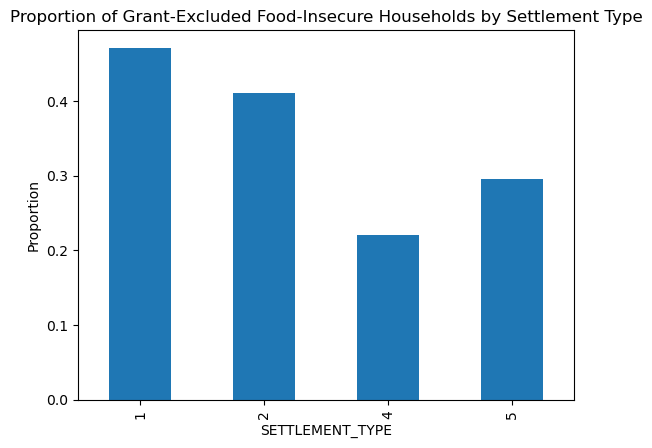

In [120]:
prop = analysis_df.groupby('SETTLEMENT_TYPE').apply(
    lambda g: (g['grant_excluded'] * g['hholds_wgt']).sum() / g['hholds_wgt'].sum()
)
prop.plot(kind='bar')
plt.title('Proportion of Grant‑Excluded Food‑Insecure Households by Settlement Type')
plt.ylabel('Proportion')
plt.show()

In [121]:
print(analysis_df['SETTLEMENT_TYPE'].value_counts())

SETTLEMENT_TYPE
4    690
1    357
2    158
5     48
Name: count, dtype: int64


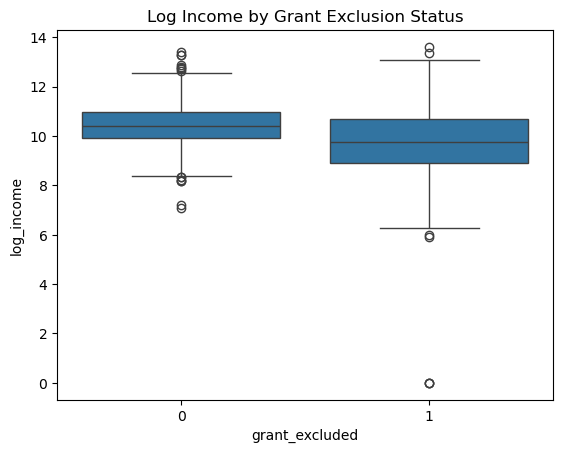

In [122]:
sns.boxplot(data=analysis_df, x='grant_excluded', y='log_income')
plt.title('Log Income by Grant Exclusion Status')
plt.show()

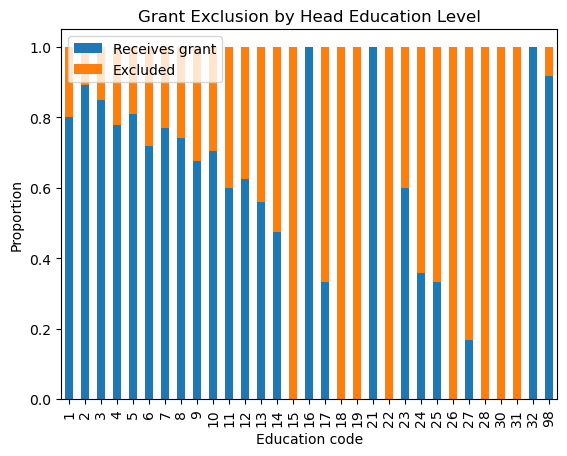

In [123]:
edu_cross = pd.crosstab(analysis_df['head_education'], analysis_df['grant_excluded'], normalize='index')
edu_cross.plot(kind='bar', stacked=True)
plt.title('Grant Exclusion by Head Education Level')
plt.xlabel('Education code')
plt.ylabel('Proportion')
plt.legend(['Receives grant', 'Excluded'])
plt.show()

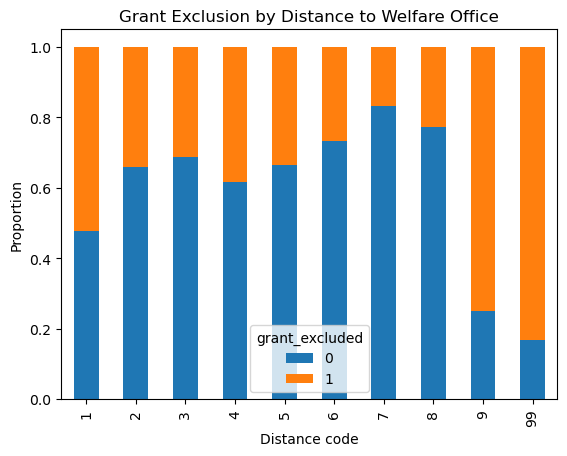

In [124]:
dist_cross = pd.crosstab(analysis_df['Q531WELFARE'], analysis_df['grant_excluded'], normalize='index')
dist_cross.plot(kind='bar', stacked=True)
plt.title('Grant Exclusion by Distance to Welfare Office')
plt.xlabel('Distance code')
plt.ylabel('Proportion')
plt.show()

In [125]:
print(f"Total KZN households: {len(kzn_hh)}")

Total KZN households: 3686


In [126]:
print("model_df shape:", model_df.shape)
print("\nColumn names (first 20):")
print(model_df.columns.tolist()[:20])
print("\nTarget distribution:")
print(model_df['grant_excluded'].value_counts())
print("\nWeights summary:")
print(model_df['hholds_wgt'].describe())

model_df shape: (1253, 357)

Column names (first 20):
['UQNO', 'grant_excluded', 'hholds_wgt', 'SURVEYDATE', 'Q11CPARTHH', 'Q11CMANY', 'Q15OTHPERS', 'Q116PRESENT', 'Q116PERSONNO', 'Q51MAIN', 'Q51OTHER', 'Q51NOOTH', 'Q52AWALLS', 'Q52AROOF', 'Q52BMATFLOOR', 'Q53WALLS', 'Q53ROOF', 'Q53FLOOR', 'Q54ADWELLING', 'Q54AOTHER']

Target distribution:
grant_excluded
0    901
1    352
Name: count, dtype: int64

Weights summary:
count    1253.000000
mean      714.126552
std       387.614019
min       333.517208
25%       474.807116
50%       580.443723
75%       755.656777
max      3313.385427
Name: hholds_wgt, dtype: float64


In [127]:
print(model_df['log_income'].describe())

count    1253.000000
mean       10.245209
std         1.181266
min         0.000000
25%         9.705079
50%        10.333553
75%        10.893760
max        13.611793
Name: log_income, dtype: float64


In [128]:
numeric_cols = ['log_income']
corr_with_target = model_df[numeric_cols + ['grant_excluded']].corr()['grant_excluded'].drop('grant_excluded')
print(corr_with_target)

log_income   -0.253373
Name: grant_excluded, dtype: float64


In [129]:
print(model_df.isnull().sum().sum())

505


In [130]:
missing_counts = model_df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
print(missing_cols)

Q655YEAR    505
dtype: int64


In [131]:
if 'Q655YEAR' in model_df.columns:
    model_df = model_df.drop(columns=['Q655YEAR'])

In [132]:
print(model_df.isnull().sum().sum()) 

0


In [133]:
print(model_df.columns.tolist())

['UQNO', 'grant_excluded', 'hholds_wgt', 'SURVEYDATE', 'Q11CPARTHH', 'Q11CMANY', 'Q15OTHPERS', 'Q116PRESENT', 'Q116PERSONNO', 'Q51MAIN', 'Q51OTHER', 'Q51NOOTH', 'Q52AWALLS', 'Q52AROOF', 'Q52BMATFLOOR', 'Q53WALLS', 'Q53ROOF', 'Q53FLOOR', 'Q54ADWELLING', 'Q54AOTHER', 'Q54BSTATESUB', 'Q55INDIGENT', 'Q56DRINK', 'Q56OTHER', 'Q57DRINK', 'Q57OTHER', 'Q58PIPE', 'Q59CLEAR', 'Q59TASTE', 'Q59SMELL', 'Q59SAFE', 'Q510TREAT', 'Q511SUPPLY', 'Q512INTERUPT', 'Q513REASON', 'Q514LONGTWO', 'Q515PAYWAT', 'Q516REASON', 'Q517FREEWAT', 'Q518TOILET', 'Q519SEWERAGE', 'Q520SHARETOIL', 'Q521TOILETLOC', 'Q522DISTANCE', 'Q523FREESANI', 'Q524ELECT', 'Q525AMAINS', 'Q525BSOURCE', 'Q526FREEELCET', 'Q527COOK', 'Q527LIGHT', 'Q527WATER', 'Q527SPACE', 'Q528REFUSE', 'Q529FREEREF', 'Q530MAIL', 'Q531FOOD', 'Q531PUBTRAN', 'Q531PREPRIM', 'Q531PRIM', 'Q531SECOND', 'Q531CLINIC', 'Q531HOSPITAL', 'Q531POLICE', 'Q531RELIG', 'Q531BANK', 'Q531POSTOFF', 'Q531MULTI', 'Q532FOOD', 'Q532PUBTRAN', 'Q532PREPRIM', 'Q532PRIM', 'Q532SECOND', 'Q

In [134]:
raw_predictors = ['hhsize', 'head_education', 'total_hh_income', 
                  'Q531WELFARE', 'Q532WELFARE', 'SETTLEMENT_TYPE', 
                  'SexOfHead', 'head_employed']

In [135]:
for col in raw_predictors:
    if col in analysis_df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ {col} (missing)")

✓ hhsize
✓ head_education
✓ total_hh_income
✓ Q531WELFARE
✓ Q532WELFARE
✓ SETTLEMENT_TYPE
✓ SexOfHead
✓ head_employed


In [136]:
model_prep = analysis_df[raw_predictors + ['grant_excluded', 'hholds_wgt']].copy()

In [137]:
num_cols = ['hhsize', 'total_hh_income']
for col in num_cols:
    model_prep[col] = model_prep[col].fillna(model_prep[col].mean())

In [138]:
cat_cols = ['head_education', 'Q531WELFARE', 'Q532WELFARE', 
            'SETTLEMENT_TYPE', 'SexOfHead', 'head_employed']
for col in cat_cols:
    mode_val = model_prep[col].mode()[0] if not model_prep[col].mode().empty else 0
    model_prep[col] = model_prep[col].fillna(mode_val)

In [139]:
print(model_prep.isnull().sum())

hhsize             0
head_education     0
total_hh_income    0
Q531WELFARE        0
Q532WELFARE        0
SETTLEMENT_TYPE    0
SexOfHead          0
head_employed      0
grant_excluded     0
hholds_wgt         0
dtype: int64


In [140]:
model_prep['log_income'] = np.log1p(model_prep['total_hh_income'])

In [141]:
categoricals = ['head_education', 'Q531WELFARE', 'Q532WELFARE', 
                'SETTLEMENT_TYPE', 'SexOfHead', 'head_employed']

model_encoded = pd.get_dummies(model_prep, columns=categoricals, drop_first=True)

In [142]:
print(model_encoded.isnull().sum().sum())

0


In [143]:
model_encoded = model_encoded.drop(columns=['total_hh_income'])

In [144]:
print(model_encoded.shape)
print(model_encoded.columns.tolist())

(1253, 54)
['hhsize', 'grant_excluded', 'hholds_wgt', 'log_income', 'head_education_2', 'head_education_3', 'head_education_4', 'head_education_5', 'head_education_6', 'head_education_7', 'head_education_8', 'head_education_9', 'head_education_10', 'head_education_11', 'head_education_12', 'head_education_13', 'head_education_14', 'head_education_15', 'head_education_16', 'head_education_17', 'head_education_18', 'head_education_19', 'head_education_21', 'head_education_22', 'head_education_23', 'head_education_24', 'head_education_25', 'head_education_26', 'head_education_27', 'head_education_28', 'head_education_30', 'head_education_31', 'head_education_32', 'head_education_98', 'Q531WELFARE_2', 'Q531WELFARE_3', 'Q531WELFARE_4', 'Q531WELFARE_5', 'Q531WELFARE_6', 'Q531WELFARE_7', 'Q531WELFARE_8', 'Q531WELFARE_9', 'Q531WELFARE_99', 'Q532WELFARE_2', 'Q532WELFARE_3', 'Q532WELFARE_4', 'Q532WELFARE_5', 'Q532WELFARE_6', 'Q532WELFARE_9', 'SETTLEMENT_TYPE_2', 'SETTLEMENT_TYPE_4', 'SETTLEMENT_

In [145]:
print(model_encoded.isnull().sum().sum())

0


In [146]:
print(model_encoded['grant_excluded'].value_counts())

grant_excluded
0    901
1    352
Name: count, dtype: int64


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [148]:
X = model_encoded.drop(columns=['grant_excluded', 'hholds_wgt'])
y = model_encoded['grant_excluded']
w = model_encoded['hholds_wgt']

In [149]:
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (1253, 52)
y distribution:
 grant_excluded
0    901
1    352
Name: count, dtype: int64


In [150]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train target distribution:\n", y_train.value_counts())
print("Test target distribution:\n", y_test.value_counts())

Train size: 1002
Test size: 251
Train target distribution:
 grant_excluded
0    721
1    281
Name: count, dtype: int64
Test target distribution:
 grant_excluded
0    180
1     71
Name: count, dtype: int64


In [151]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE - train size:", X_train_res.shape[0])
print("After SMOTE - target distribution:\n", y_train_res.value_counts())

After SMOTE - train size: 1442
After SMOTE - target distribution:
 grant_excluded
0    721
1    721
Name: count, dtype: int64


  File "C:\Users\oluhl\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\oluhl\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\oluhl\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\oluhl\anaconda3\Lib\subprocess.

In [152]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Grant Recipient', 'Grant Excluded']))
    return model, y_proba

In [153]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr, lr_proba = evaluate_model(lr, X_train_res, y_train_res, X_test, y_test, "Logistic Regression")


Logistic Regression
Accuracy: 0.8167
ROC-AUC: 0.8826
                 precision    recall  f1-score   support

Grant Recipient       0.90      0.84      0.87       180
 Grant Excluded       0.65      0.76      0.70        71

       accuracy                           0.82       251
      macro avg       0.77      0.80      0.78       251
   weighted avg       0.83      0.82      0.82       251



In [154]:
dt = DecisionTreeClassifier(random_state=42)
dt, dt_proba = evaluate_model(dt, X_train_res, y_train_res, X_test, y_test, "Decision Tree")


Decision Tree
Accuracy: 0.7928
ROC-AUC: 0.7489
                 precision    recall  f1-score   support

Grant Recipient       0.86      0.85      0.85       180
 Grant Excluded       0.63      0.65      0.64        71

       accuracy                           0.79       251
      macro avg       0.74      0.75      0.75       251
   weighted avg       0.79      0.79      0.79       251



In [155]:
rf = RandomForestClassifier(random_state=42)
rf, rf_proba = evaluate_model(rf, X_train_res, y_train_res, X_test, y_test, "Random Forest")


Random Forest
Accuracy: 0.8606
ROC-AUC: 0.8937
                 precision    recall  f1-score   support

Grant Recipient       0.88      0.93      0.91       180
 Grant Excluded       0.79      0.69      0.74        71

       accuracy                           0.86       251
      macro avg       0.84      0.81      0.82       251
   weighted avg       0.86      0.86      0.86       251



In [156]:
ada = AdaBoostClassifier(random_state=42)
ada, ada_proba = evaluate_model(ada, X_train_res, y_train_res, X_test, y_test, "AdaBoost")


AdaBoost
Accuracy: 0.8287
ROC-AUC: 0.9049
                 precision    recall  f1-score   support

Grant Recipient       0.89      0.87      0.88       180
 Grant Excluded       0.69      0.72      0.70        71

       accuracy                           0.83       251
      macro avg       0.79      0.80      0.79       251
   weighted avg       0.83      0.83      0.83       251



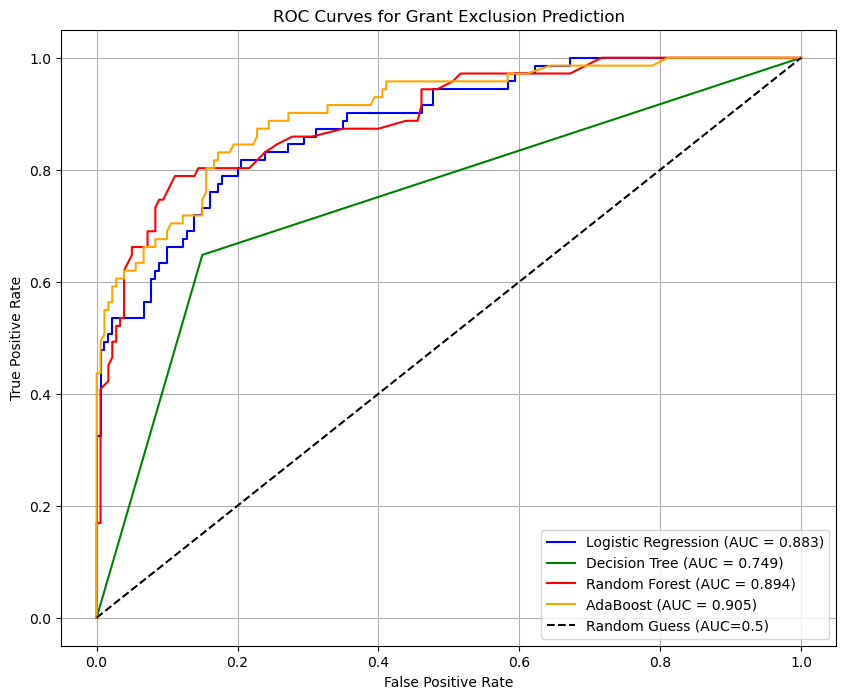

In [157]:
plt.figure(figsize=(10, 8))

def add_roc_curve(y_test, proba, label, color):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", color=color)

add_roc_curve(y_test, lr_proba, "Logistic Regression", "blue")
add_roc_curve(y_test, dt_proba, "Decision Tree", "green")
add_roc_curve(y_test, rf_proba, "Random Forest", "red")
add_roc_curve(y_test, ada_proba, "AdaBoost", "orange")

plt.plot([0,1], [0,1], 'k--', label="Random Guess (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Grant Exclusion Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [158]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf_base, param_dist, n_iter=10, cv=3, 
                                   scoring='roc_auc', n_jobs=-1, random_state=42)
random_search.fit(X_train_res, y_train_res)

print("Best parameters:", random_search.best_params_)
print("Best cross-validated ROC-AUC:", random_search.best_score_)

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:,1]
print("\nTuned Random Forest on test set:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))
print(classification_report(y_test, y_pred_best, target_names=['Grant Recipient', 'Grant Excluded']))

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best cross-validated ROC-AUC: 0.[REDACTED]

Tuned Random Forest on test set:
Accuracy: 0.[REDACTED]
ROC-AUC: 0.[REDACTED]
                 precision    recall  f1-score   support

Grant Recipient       0.88      0.92      0.90       180
 Grant Excluded       0.77      0.69      0.73        71

       accuracy                           0.85       251
      macro avg       0.82      0.80      0.81       251
   weighted avg       0.85      0.85      0.85       251



In [159]:
import statsmodels.api as sm

In [160]:
bool_cols = X_train.select_dtypes(include=['bool']).columns
X_train[bool_cols] = X_train[bool_cols].astype(int)

In [161]:
X_train = X_train.astype(float)


In [162]:
constant_cols = []
for col in X_train.columns:
    if X_train[col].nunique() == 1:
        constant_cols.append(col)
        print(f"{col} is constant = {X_train[col].iloc[0]}")

if constant_cols:
    X_train = X_train.drop(columns=constant_cols)

head_education_28 is constant = 0.0
head_education_31 is constant = 0.0


In [163]:
X_train_arr = X_train.astype(float).values
X_train_const = sm.add_constant(X_train_arr)
rank = np.linalg.matrix_rank(X_train_const)
print(f"Rank: {rank}, columns: {X_train_const.shape[1]}")

Rank: 51, columns: 51


In [164]:
for col in X_train.columns:
    if X_train[col].nunique() == 1 and X_train[col].iloc[0] == 1:
        print(f"Column {col} is constant 1")

In [165]:
X_train_arr = X_train.astype(float).values
# Remove any column that is all ones (if present)
cols_to_keep = [i for i, col in enumerate(X_train.columns) if X_train[col].nunique() != 1 or X_train[col].iloc[0] != 1]
X_train_arr = X_train_arr[:, cols_to_keep]

In [166]:
X_train_const = sm.add_constant(X_train_arr)


In [167]:
print("Constant column unique values:", np.unique(X_train_const[:,0]))


Constant column unique values: [1.]


In [168]:
import statsmodels.api as sm
import numpy as np

# Convert to numpy arrays (float)
X_arr = X_train.astype(float).values
y_arr = y_train.astype(float).values
w_arr = w_train.astype(float).values

# Remove any column that is constant (all values identical)
# This prevents issues when adding constant
constant_cols = [i for i in range(X_arr.shape[1]) if np.allclose(X_arr[:, i], X_arr[0, i])]
if constant_cols:
    X_arr = np.delete(X_arr, constant_cols, axis=1)
    print(f"Removed constant columns: {constant_cols}")

# Add constant
X_const = sm.add_constant(X_arr)

# Fit regularized logistic regression (L1 penalty)
# alpha=0.01 is a small regularization strength; adjust if needed
lr_weighted = sm.Logit(y_arr, X_const, weights=w_arr).fit_regularized(method='l1', alpha=0.01, disp=0)

print(lr_weighted.summary())

C:\Users\oluhl\anaconda3\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1002
Model:                          Logit   Df Residuals:                      951
Method:                           MLE   Df Model:                           50
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4706
Time:                        22:36:20   Log-Likelihood:                -314.73
converged:                       True   LL-Null:                       -594.55
Covariance Type:            nonrobust   LLR p-value:                 2.793e-87
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7164      2.157      3.114      0.002       2.490      10.943
x1            -0.6061      0.064     -9.527      0.000      -0.731      -0.481
x2            -0.5188      0.115     -4.504      0.0

C:\Users\oluhl\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 21 out of 51 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\oluhl\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\oluhl\anaconda3\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


In [169]:
# The names of the columns in X_train (before any constant or removal)
var_names = X_train.columns.tolist()

# If we removed constant columns earlier, we need the same subset
# Assuming we used the same X_train_arr creation steps, we can get the retained indices
# In the code we had: 
# constant_cols = [i for i in range(X_arr.shape[1]) if np.allclose(X_arr[:, i], X_arr[0, i])]
# X_arr = np.delete(X_arr, constant_cols, axis=1)
# Then added constant, so the final coefficients correspond to:
# [const] + [var_names[i] for i in range(len(var_names)) if i not in constant_cols]

# Let's reconstruct the final column order used in the model
# (We need to be careful because we might have dropped columns due to constant, and also added constant)
# The model's param names are ['const', 'x1', 'x2', ..., 'x50'] in that order.
# We can create a mapping:

# Get the indices of non-constant columns
non_const_indices = [i for i in range(X_train.shape[1]) if not np.allclose(X_train.iloc[:, i], X_train.iloc[0, i])]
final_col_names = [X_train.columns[i] for i in non_const_indices]

# Now the coefficients correspond to:
# const, then final_col_names[0], final_col_names[1], ...
print("Coefficient mapping:")
for i, name in enumerate(final_col_names):
    print(f"x{i+1} -> {name}")

Coefficient mapping:
x1 -> hhsize
x2 -> log_income
x3 -> head_education_2
x4 -> head_education_3
x5 -> head_education_4
x6 -> head_education_5
x7 -> head_education_6
x8 -> head_education_7
x9 -> head_education_8
x10 -> head_education_9
x11 -> head_education_10
x12 -> head_education_11
x13 -> head_education_12
x14 -> head_education_13
x15 -> head_education_14
x16 -> head_education_15
x17 -> head_education_16
x18 -> head_education_17
x19 -> head_education_18
x20 -> head_education_19
x21 -> head_education_21
x22 -> head_education_22
x23 -> head_education_23
x24 -> head_education_24
x25 -> head_education_25
x26 -> head_education_26
x27 -> head_education_27
x28 -> head_education_30
x29 -> head_education_32
x30 -> head_education_98
x31 -> Q531WELFARE_2
x32 -> Q531WELFARE_3
x33 -> Q531WELFARE_4
x34 -> Q531WELFARE_5
x35 -> Q531WELFARE_6
x36 -> Q531WELFARE_7
x37 -> Q531WELFARE_8
x38 -> Q531WELFARE_9
x39 -> Q531WELFARE_99
x40 -> Q532WELFARE_2
x41 -> Q532WELFARE_3
x42 -> Q532WELFARE_4
x43 -> Q532

In [170]:
import pandas as pd
import numpy as np

In [171]:
params = lr_weighted.params
pvals = lr_weighted.pvalues
conf_low, conf_high = lr_weighted.conf_int().T

In [172]:
import numpy as np
import pandas as pd

# Identify non‑constant columns in X_train
non_const_indices = []
for i, col in enumerate(X_train.columns):
    if not np.allclose(X_train.iloc[:, i], X_train.iloc[0, i]):
        non_const_indices.append(i)

# Final variable names (excluding constant)
final_var_names = [X_train.columns[i] for i in non_const_indices]

# Extract model outputs
params = lr_weighted.params
pvals = lr_weighted.pvalues
conf_int = lr_weighted.conf_int()

# Handle confidence intervals (could be array or DataFrame)
if hasattr(conf_int, 'values'):
    conf_low = conf_int.values[:, 0]
    conf_high = conf_int.values[:, 1]
else:
    conf_low = conf_int[:, 0]
    conf_high = conf_int[:, 1]

# Build results DataFrame
results_df = pd.DataFrame({
    'Variable': ['const'] + final_var_names,
    'Coef': params,
    'P>|z|': pvals,
    'CI_lower': conf_low,
    'CI_upper': conf_high
})

# Compute odds ratios and exponentiated CIs
results_df['Odds_Ratio'] = np.exp(results_df['Coef'])
results_df['OR_lower'] = np.exp(results_df['CI_lower'])
results_df['OR_upper'] = np.exp(results_df['CI_upper'])

# Sort by p‑value (most significant first)
results_df = results_df.sort_values('P>|z|').reset_index(drop=True)

# Show all significant predictors (p < 0.05)
sig_df = results_df[results_df['P>|z|'] < 0.05]
print(sig_df.to_string())

          Variable      Coef         P>|z|  CI_lower   CI_upper  Odds_Ratio   OR_lower      OR_upper
0           hhsize -0.606124  1.612634e-21 -0.730815  -0.481433    0.545461   0.481516      0.617897
1  head_employed_1  1.319554  4.679308e-09  0.878074   1.761035    3.741753   2.406260      5.818456
2      SexOfHead_2 -1.194671  1.886216e-08 -1.611153  -0.778190    0.302803   0.199657      0.459237
3       log_income -0.518793  6.653158e-06 -0.744526  -0.293059    0.595239   0.474959      0.745978
4            const  6.716359  1.843186e-03  2.489601  10.943118  825.805405  12.056461  56563.411312
5    Q532WELFARE_5  2.152964  1.636184e-02  0.395286   3.910642    8.610341   1.484809     49.930986
